# k-Nearest Neighbours

### The model that does no training at all

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How k-NN classifies by memory alone, how to choose k, why forgetting to scale breaks it completely, and what the curse of dimensionality actually is |
| **You should already know** | [Logistic regression](../01-logistic-regression/) |
| **Datasets** | UCI Dry Bean (13,611 × 16), Breast Cancer Wisconsin (569 × 30) |
| **Runtime** | About two minutes on a laptop CPU |
| **Next** | [03-03 Naive Bayes](../03-naive-bayes/) |

---

## 1. The idea

Every other model in this book compresses the training data into parameters and
then throws the data away. k-NN does the opposite: it keeps everything and does
no work until you ask it a question.

To classify a new bean: find the `k` training beans closest to it, and take a
vote. That is the entire algorithm. There is no loss function, no gradient, no
fitting. `fit()` is literally just storing the array.

The cost moves from training to prediction. Training is instant; every
prediction has to measure the distance to every stored point.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y = datasets.dry_bean()
print(f"{X.shape[0]:,} beans, {X.shape[1]} measurements, {y.nunique()} varieties")

13,611 beans, 16 measurements, 7 varieties


## 2. The maths

Almost all of it is one formula. The straight-line distance between two points
in $n$ dimensions:

$$d(a, b) = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}$$

Note what that sum does: **every feature contributes on its own scale**. The
Dry Bean `Area` column runs into the hundreds of thousands. `Eccentricity` runs
from 0 to 1. Squaring and adding them means area contributes roughly a hundred
billion times more to the distance than eccentricity does.

The model is not weighing the features. The units are. Section 4 measures what
that costs.

## 3. From scratch

In [2]:
class KNearestNeighboursScratch:
    """k-NN with a brute-force distance search, written out in full."""

    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # "Training" is memorising. This is the whole method.
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        out = []
        # Work in blocks so the distance matrix never exceeds a few hundred MB.
        for start in range(0, len(X), 512):
            block = X[start:start + 512]
            # (a - b)^2 expanded, so the whole block is one matrix multiply.
            distances = (np.sum(block ** 2, axis=1)[:, None]
                         + np.sum(self.X_ ** 2, axis=1)[None, :]
                         - 2 * block @ self.X_.T)
            # argpartition finds the k smallest without sorting all of them.
            nearest = np.argpartition(distances, self.k, axis=1)[:, :self.k]
            for row in self.y_[nearest]:
                values, counts = np.unique(row, return_counts=True)
                out.append(values[np.argmax(counts)])
        return np.array(out)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.25, stratify=y, random_state=SEED)

scaler = StandardScaler().fit(X_train)
mine = KNearestNeighboursScratch(k=5).fit(scaler.transform(X_train), y_train)
ours = (mine.predict(scaler.transform(X_test)) == y_test).mean()

from sklearn.neighbors import KNeighborsClassifier

theirs = KNeighborsClassifier(n_neighbors=5).fit(scaler.transform(X_train), y_train)
print(f"our k-NN     : {ours:.4f}")
print(f"sklearn k-NN : {theirs.score(scaler.transform(X_test), y_test):.4f}")

our k-NN     : 0.9230


sklearn k-NN : 0.9230


## 4. In practice

### Scaling is not optional here

For logistic regression, scaling was about interpreting coefficients. For k-NN
it changes the answer, because scale *is* the weighting.

In [3]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

unscaled = cross_val_score(KNeighborsClassifier(n_neighbors=5), X.values, y.values,
                           cv=folds, n_jobs=-1).mean()
scaled = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
                         X.values, y.values, cv=folds, n_jobs=-1).mean()

spread = X.std().sort_values(ascending=False)
print("standard deviation of each column, largest first:")
print(spread.head(4).round(1).to_string())
print(spread.tail(3).round(4).to_string())
print(f"\nk-NN without scaling : {unscaled:.4f}")
print(f"k-NN with scaling    : {scaled:.4f}")
print(f"difference           : {scaled - unscaled:+.4f}")

standard deviation of each column, largest first:
ConvexArea         29774.9
Area               29324.1
Perimeter            214.3
MajorAxisLength       85.7
ShapeFactor4    0.0044
ShapeFactor1    0.0011
ShapeFactor2    0.0006

k-NN without scaling : 0.7185
k-NN with scaling    : 0.9231
difference           : +0.2045


### Choosing k

`k` controls how much the model smooths. At `k=1` every training point defines
its own island and the model memorises noise. As `k` grows the boundary
stiffens, until at `k` equal to the dataset size it just predicts the majority
class everywhere.

k=1  : training 1.0000, held out 0.9063
k=21 : training 0.9286, held out 0.9233


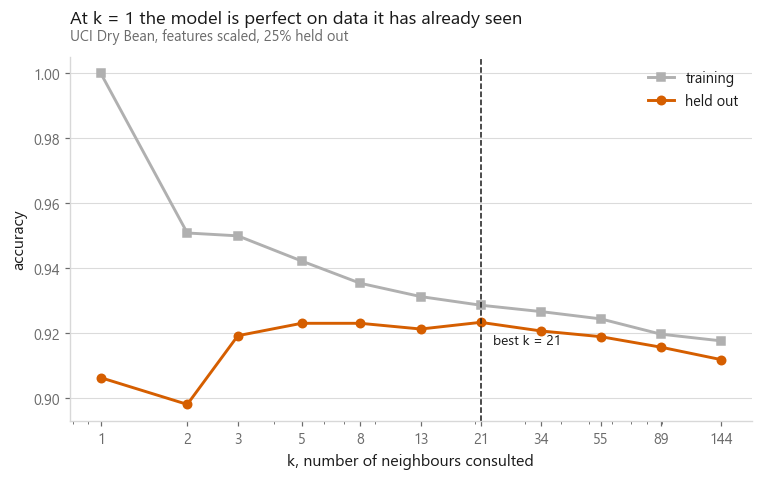

In [4]:
k_values = [1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144]
train_scores, test_scores = [], []

X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1).fit(X_train_s, y_train)
    train_scores.append(model.score(X_train_s, y_train))
    test_scores.append(model.score(X_test_s, y_test))

fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.plot(k_values, train_scores, marker=style.MARKERS[1], color=style.NEUTRAL, label="training")
ax.plot(k_values, test_scores, marker=style.MARKERS[0], color=style.HIGHLIGHT, label="held out")
best = int(np.argmax(test_scores))
ax.axvline(k_values[best], color=style.INK, ls="--", lw=1)
ax.annotate(f"best k = {k_values[best]}", xy=(k_values[best], test_scores[best]),
            xytext=(8, -14), textcoords="offset points", fontsize=9, color=style.INK)
ax.set_xscale("log")
ax.set_xticks(k_values, [str(k) for k in k_values])
ax.set_xlabel("k, number of neighbours consulted")
ax.set_ylabel("accuracy")
ax.legend()
style.title(ax, "At k = 1 the model is perfect on data it has already seen",
            "UCI Dry Bean, features scaled, 25% held out")
style.save(fig, FIG / "fig-01-choosing-k.png")

print(f"k=1  : training {train_scores[0]:.4f}, held out {test_scores[0]:.4f}")
print(f"k={k_values[best]:<3}: training {train_scores[best]:.4f}, held out {test_scores[best]:.4f}")

The `k=1` training score is the clearest picture of overfitting anywhere in this
book. It is exactly 1.000, and it has to be: the nearest neighbour of any
training point is **itself**, at distance zero. The model has learned nothing
and scores perfectly. Any evaluation that trusts training accuracy would call
this the best model available.

## 5. When it wins, when it loses

k-NN's reputation is that it dies in high dimensions. The reason is worth seeing
rather than repeating: as dimensions grow, **distances stop discriminating**. The
nearest point and the farthest point end up almost equally far away, and once
that happens "nearest" carries no information.

distance ratio at 1 dimension    : 4572.2
distance ratio at 1000 dimensions: 1.15

k-NN      with 0 noise columns: 0.9649, with 400: 0.8559
logistic  with 0 noise columns: 0.9807, with 400: 0.9403


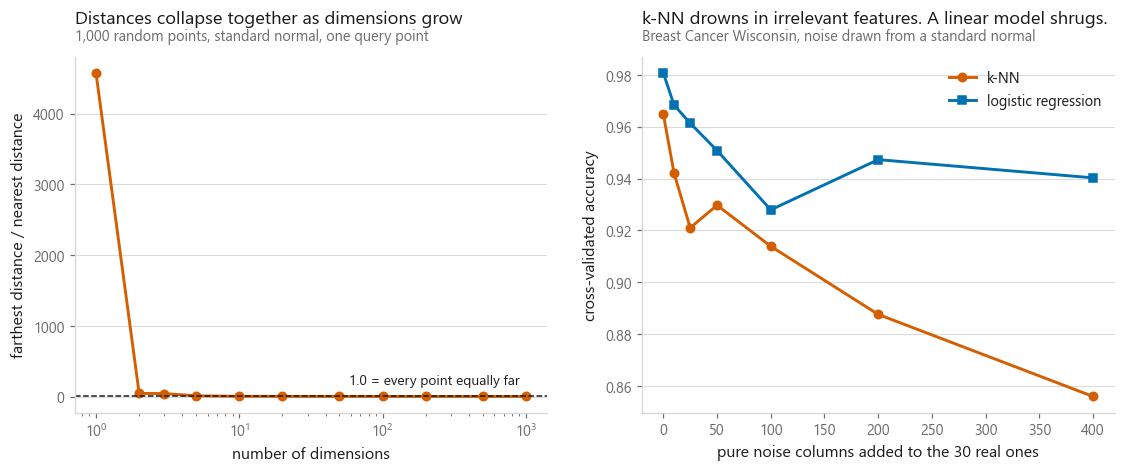

In [5]:
rng = np.random.default_rng(SEED)
dimensions = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000]
ratios = []

for d in dimensions:
    cloud = rng.normal(size=(1000, d))
    query = rng.normal(size=(1, d))
    distance = np.sqrt(((cloud - query) ** 2).sum(axis=1))
    # How much further is the farthest point than the nearest one?
    ratios.append(distance.max() / distance.min())

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))

axes[0].plot(dimensions, ratios, marker=style.MARKERS[0], color=style.HIGHLIGHT)
axes[0].axhline(1.0, color=style.INK, ls="--", lw=1)
axes[0].annotate("1.0 = every point equally far", xy=(1000, 1.0), xytext=(-4, 8),
                 textcoords="offset points", ha="right", fontsize=9, color=style.INK)
axes[0].set_xscale("log")
axes[0].set_xlabel("number of dimensions")
axes[0].set_ylabel("farthest distance / nearest distance")
style.title(axes[0], "Distances collapse together as dimensions grow",
            "1,000 random points, standard normal, one query point")

# And what that does to accuracy: add pure noise columns to a real dataset.
X_bc, y_bc = datasets.breast_cancer()
noise_counts = [0, 10, 25, 50, 100, 200, 400]
knn_curve, logistic_curve = [], []

from sklearn.linear_model import LogisticRegression

for extra in noise_counts:
    padded = np.hstack([X_bc.values, rng.normal(size=(len(X_bc), extra))]) if extra else X_bc.values
    knn_curve.append(cross_val_score(
        make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        padded, y_bc.values, cv=5, n_jobs=-1).mean())
    logistic_curve.append(cross_val_score(
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
        padded, y_bc.values, cv=5, n_jobs=-1).mean())

axes[1].plot(noise_counts, knn_curve, marker=style.MARKERS[0], color=style.HIGHLIGHT, label="k-NN")
axes[1].plot(noise_counts, logistic_curve, marker=style.MARKERS[1], color=style.PALETTE[0],
             label="logistic regression")
axes[1].set_xlabel("pure noise columns added to the 30 real ones")
axes[1].set_ylabel("cross-validated accuracy")
axes[1].legend()
style.title(axes[1], "k-NN drowns in irrelevant features. A linear model shrugs.",
            "Breast Cancer Wisconsin, noise drawn from a standard normal")

style.save(fig, FIG / "fig-02-curse-of-dimensionality.png")

print(f"distance ratio at 1 dimension    : {ratios[0]:.1f}")
print(f"distance ratio at 1000 dimensions: {ratios[-1]:.2f}")
print(f"\nk-NN      with 0 noise columns: {knn_curve[0]:.4f}, with 400: {knn_curve[-1]:.4f}")
print(f"logistic  with 0 noise columns: {logistic_curve[0]:.4f}, with 400: {logistic_curve[-1]:.4f}")

The left panel is the curse itself. In one dimension the farthest of a thousand
random points is many times farther than the nearest. By a thousand dimensions
the ratio has fallen close to 1, meaning every point is essentially the same
distance away. "Nearest" has stopped meaning anything.

The right panel shows the practical consequence. Adding pure noise columns —
containing no information whatsoever — steadily destroys k-NN, because every
noise column adds its own contribution to every distance. Logistic regression
suffers too, but far less, because it can give a useless feature a weight near
zero. **k-NN has no weights, so it cannot ignore anything** — every column votes
on what counts as "near", whether or not it knows anything.

That is the honest summary of when to use it: k-NN wants few features, all of
them relevant, all of them scaled.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Few features and all relevant; the boundary is irregular; you want a strong non-linear baseline with no training |
| **Avoid it when** | Many features, many irrelevant features, large datasets where prediction must be fast, or a lot of missing data |
| **Scaling needed** | Absolutely. Without it the largest-unit column *is* the model |
| **Cost** | Training free. Prediction is $O(\text{rows} \times \text{features})$ per query, which is the real limitation |
| **Main dials** | `n_neighbors`, `weights` (uniform or distance), `metric`, `p` for Minkowski |
| **Watch out** | `k=1` scores 1.000 on training data by construction. Never judge k-NN on training accuracy |
| **Next** | [Naive Bayes](../03-naive-bayes/), which handles many features by assuming they are independent |

## What to remember

1. k-NN memorises. `fit()` stores the array; all the work happens at prediction.
2. Distance sums squared differences, so unscaled features are silently weighted
   by their units.
3. Small `k` overfits, large `k` smooths toward the majority class.
4. `k=1` always scores perfectly on training data. That number is meaningless.
5. The curse of dimensionality is measurable: distances converge, and irrelevant
   features degrade k-NN in a way they do not degrade weighted models.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [03-03 Naive Bayes](../03-naive-bayes/) · Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#KNN` `#KNearestNeighbours` `#Classification` `#Python`
`#ScikitLearn` `#DataScience` `#MLTutorial` `#CurseOfDimensionality`